In [1]:
import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import pygmt

# Grow the GPU memory usage as needed
gpus = tf.config.experimental.list_physical_devices("GPU")
if gpus:
    try:
        # Currently, memory growth needs to be the same across GPUs
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.experimental.list_logical_devices("GPU")
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print(e)

import nn_gmm

2022-05-11 13:41:24.739932: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:939] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-05-11 13:41:24.746516: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:939] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-05-11 13:41:24.746825: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:939] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-05-11 13:41:24.747937: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropri

1 Physical GPUs, 1 Logical GPUs


In [2]:
source_params_dir = Path("/home/claudy/dev/work/data/nn_gmm/input_data/source_rel_params")

im_data_ffps = list(Path("/home/claudy/dev/work/data/nn_gmm/input_data/im_data").glob("*.h5"))

In [3]:
print("Loading realisation params")
rel_df = nn_gmm.load_dfs(
    list(source_params_dir.glob("*.csv")), index_col="realisation"
)
rel_df["source"] = [
    split_list[0]
    for split_list in np.char.split(rel_df.index.values.astype(str), "_")
]
assert (
    np.unique(rel_df.index.values.astype(str)).shape[0]
    == rel_df.shape[0]
)

Loading realisation params


In [4]:
idx_values = []

# Get full set of sample combinations
for cur_imdb_ffp in im_data_ffps:
    with pd.HDFStore(cur_imdb_ffp, mode="r") as db:
        for cur_key in db.keys():
            idx_values.append(db[cur_key].index.values.astype(str))

idx_values = np.concatenate(idx_values)

In [5]:
sample_df = nn_gmm.create_sample_comb(pd.DataFrame(index=idx_values))

In [6]:
sample_df["mag"] = rel_df.loc[sample_df.realisation, "mag"].values

In [7]:
sample_df

,source,realisation,site,mag
AhuririR_REL29_0200047,AhuririR,AhuririR_REL29,0200047,6.833392
AhuririR_REL29_020005a,AhuririR,AhuririR_REL29,020005a,6.833392
AhuririR_REL29_020005b,AhuririR,AhuririR_REL29,020005b,6.833392
AhuririR_REL29_020006d,AhuririR,AhuririR_REL29,020006d,6.833392
AhuririR_REL29_020006e,AhuririR,AhuririR_REL29,020006e,6.833392
...,...,...,...,...
3792018_3792018_TOKS,3792018,3792018,TOKS,4.900000
3792018_3792018_TPLC,3792018,3792018,TPLC,4.900000
3792018_3792018_WAKC,3792018,3792018,WAKC,4.900000
3792018_3792018_WCSS,3792018,3792018,WCSS,4.900000


In [8]:
# Compute realisation bins
n_bins = 20

count, bins = np.histogram(rel_df.mag, bins=n_bins)

bin_ind = np.digitize(rel_df.mag.values, bins)

# Histogram includes the right bin edge, but
# digitize does not
bin_ind[bin_ind > n_bins] = n_bins

# Digitize also indices from 1
# (as 0 is used for values out of bounds)
bin_ind -= 1

In [9]:
# Compute the bin weights
bin_weights = 1 / count

rel_weights = bin_weights[bin_ind]

In [10]:
# Apply weights to samples
sample_bin_ind = np.digitize(sample_df.mag.values, bins)
sample_bin_ind[sample_bin_ind > n_bins] = n_bins
sample_bin_ind -= 1

sample_weights = bin_weights[sample_bin_ind]

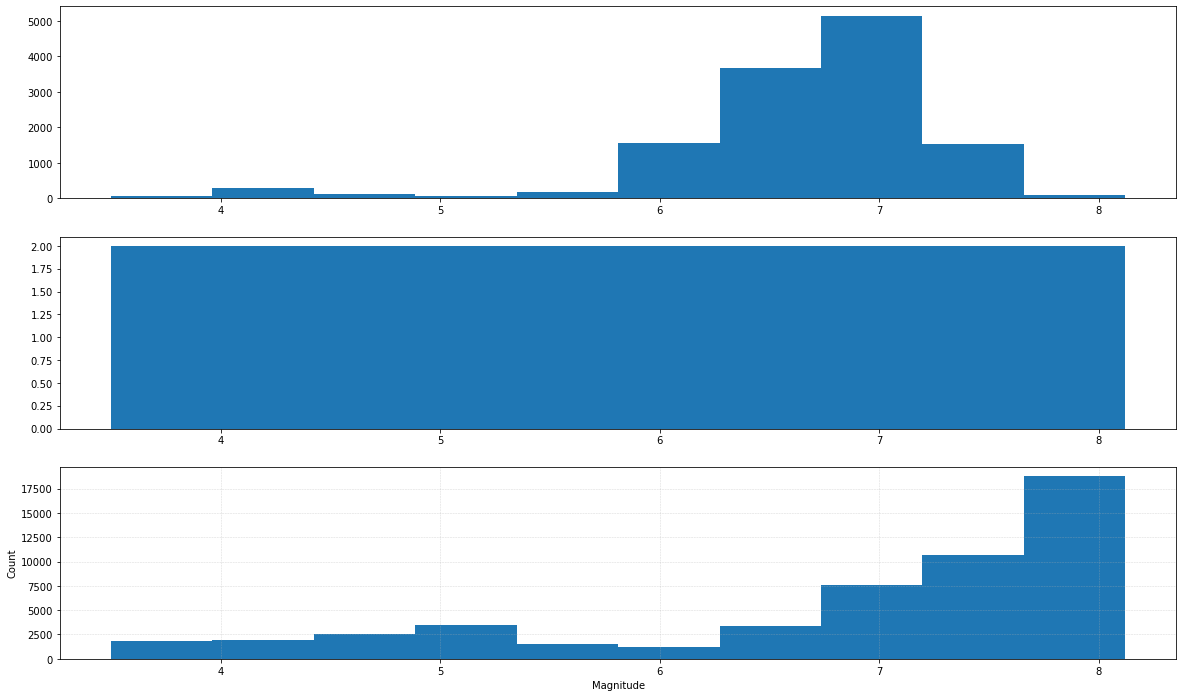

In [11]:
fig = plt.figure(figsize=(20, 12))

ax_1 = fig.add_subplot(3, 1, 1)
ax_1.hist(rel_df.mag.values)


ax_2 = fig.add_subplot(3, 1, 2, sharex=ax_1)
ax_2.hist(rel_df.mag.values, weights=rel_weights)

ax_3 = fig.add_subplot(3, 1, 3, sharex=ax_1)
ax_3.hist(sample_df.mag.values, weights=sample_weights)

ax_3.set_xlabel(f"Magnitude")
ax_3.set_ylabel(f"Count")
ax_3.grid(linewidth=0.5, alpha=0.5, linestyle="--")


-> Definitely need to apply weighting to the samples directly, not the realisations

In [12]:
# Compute sample bins
n_bins = 20

count, bins = np.histogram(sample_df.mag, bins=n_bins)

sample_bin_ind = np.digitize(sample_df.mag.values, bins)

# Histogram includes the right bin edge, but
# digitize does not
sample_bin_ind[sample_bin_ind > n_bins] = n_bins

# Digitize also indices from 1
# (as 0 is used for values out of bounds)
sample_bin_ind -= 1

In [25]:
# Compute the bin weights
bin_weights = 1 / count

sample_weights = bin_weights[sample_bin_ind]

In [14]:
# Apply to realisations
rel_bin_ind = np.digitize(rel_df.mag.values, bins)
rel_bin_ind[rel_bin_ind > n_bins] = n_bins
rel_bin_ind -= 1

rel_weights = bin_weights[rel_bin_ind]

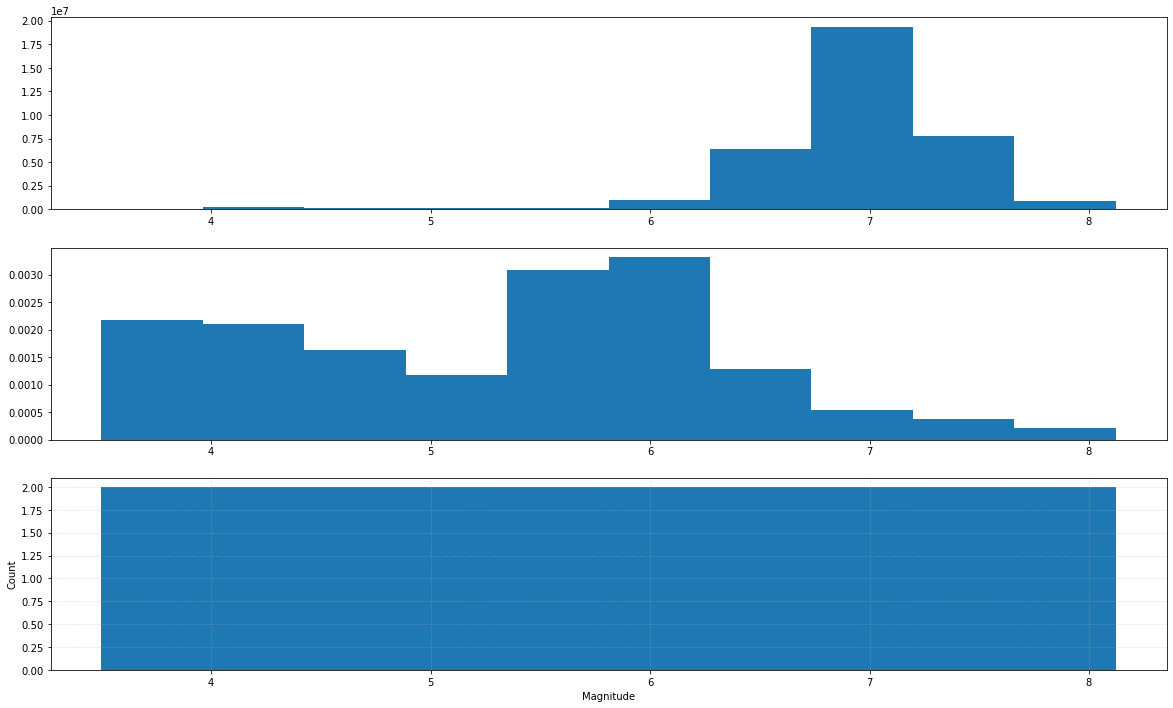

In [15]:
fig = plt.figure(figsize=(20, 12))

ax_1 = fig.add_subplot(3, 1, 1)
ax_1.hist(sample_df.mag.values)


ax_2 = fig.add_subplot(3, 1, 2, sharex=ax_1)
ax_2.hist(rel_df.mag.values, weights=rel_weights)

ax_3 = fig.add_subplot(3, 1, 3, sharex=ax_1)
ax_3.hist(sample_df.mag.values, weights=sample_weights)

ax_3.set_xlabel(f"Magnitude")
ax_3.set_ylabel(f"Count")
ax_3.grid(linewidth=0.5, alpha=0.5, linestyle="--")

In [26]:
# Normalise to number of data points
sample_weights = sample_weights * (sample_df.shape[0] / sample_weights.sum())

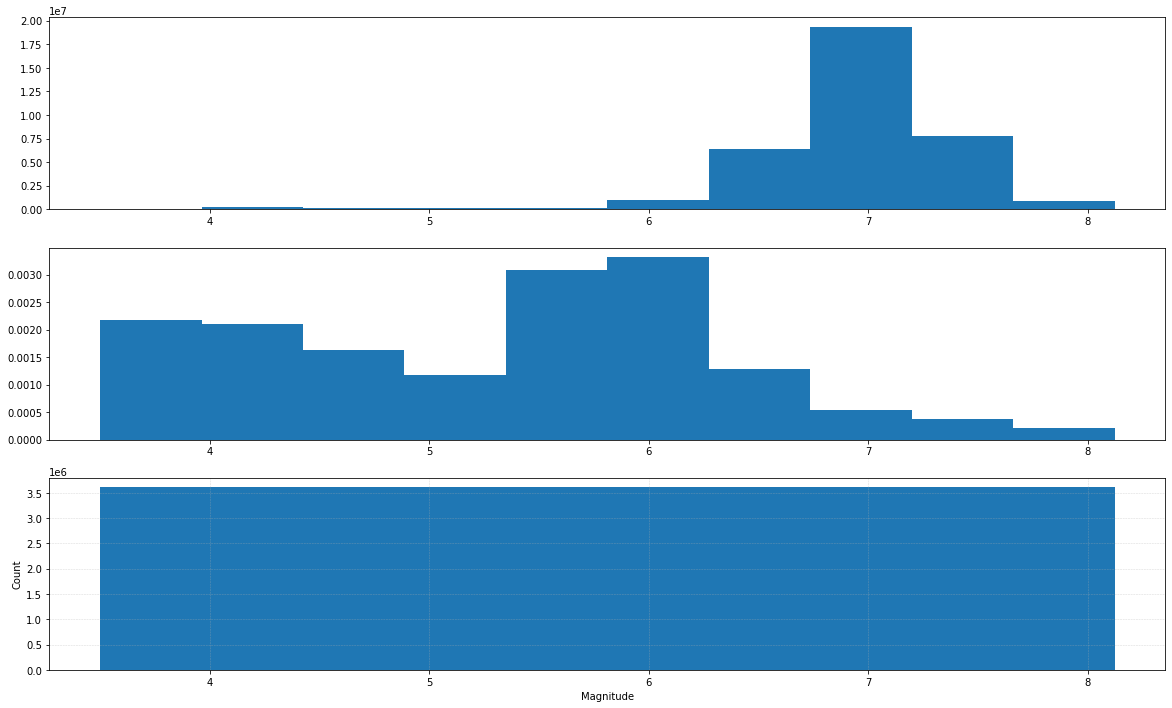

In [17]:
fig = plt.figure(figsize=(20, 12))

ax_1 = fig.add_subplot(3, 1, 1)
ax_1.hist(sample_df.mag.values)


ax_2 = fig.add_subplot(3, 1, 2, sharex=ax_1)
ax_2.hist(rel_df.mag.values, weights=rel_weights)

ax_3 = fig.add_subplot(3, 1, 3, sharex=ax_1)
ax_3.hist(sample_df.mag.values, weights=sample_weights)

ax_3.set_xlabel(f"Magnitude")
ax_3.set_ylabel(f"Count")
ax_3.grid(linewidth=0.5, alpha=0.5, linestyle="--")

0.16822469865525494 187.7364575760718


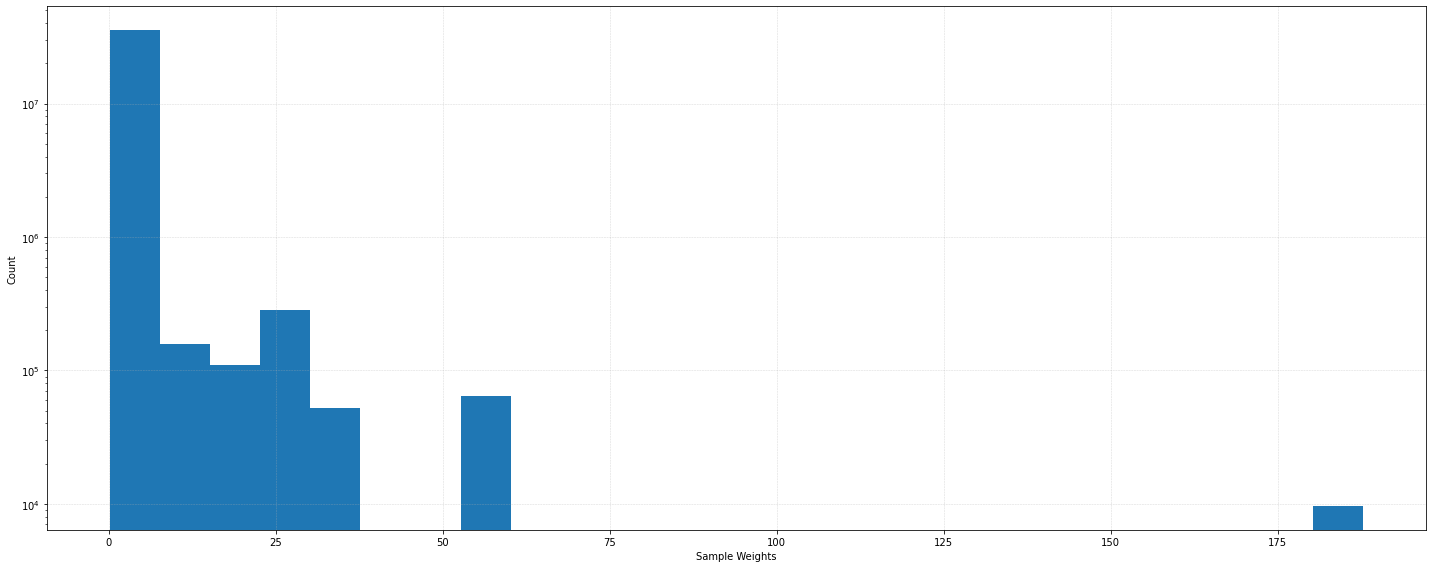

In [21]:
# Original sample weights distribution
fig = plt.figure(figsize=(20, 8))

plt.hist(sample_weights, bins=25, log=True)

plt.xlabel(f"Sample Weights")
plt.ylabel(f"Count")
plt.grid(linewidth=0.5, alpha=0.5, linestyle="--")
plt.tight_layout()

print(sample_weights.min(), sample_weights.max())

In [28]:
# Apply a max sample weight treshold
sample_weights[sample_weights > 20.0] = 20.0

0.16822469865525494 20.0


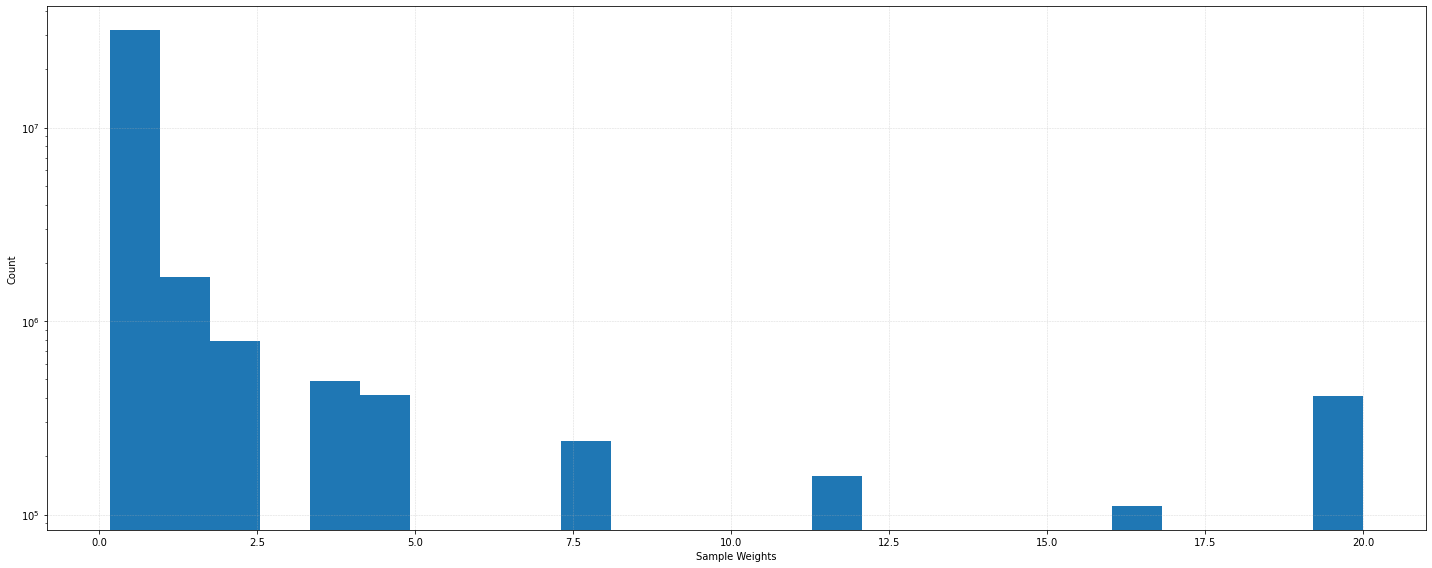

In [29]:
# Updated distribution
fig = plt.figure(figsize=(20, 8))

plt.hist(sample_weights, bins=25, log=True)

plt.xlabel(f"Sample Weights")
plt.ylabel(f"Count")
plt.grid(linewidth=0.5, alpha=0.5, linestyle="--")
plt.tight_layout()

print(sample_weights.min(), sample_weights.max())

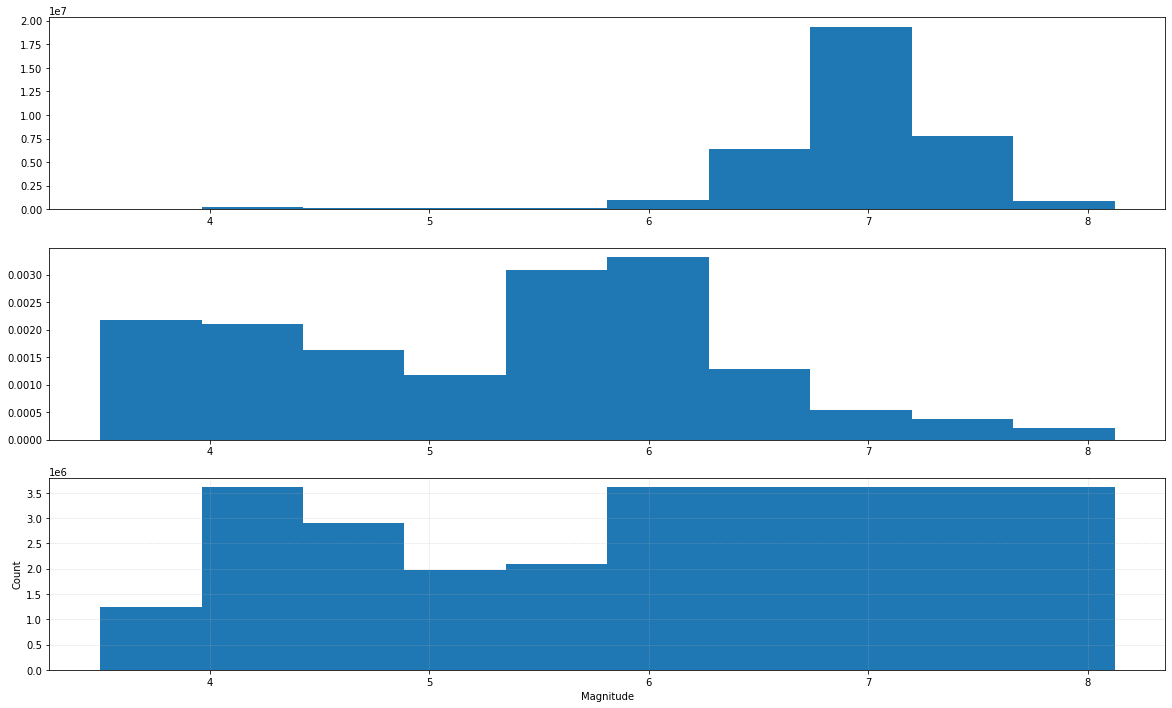

In [30]:
fig = plt.figure(figsize=(20, 12))

ax_1 = fig.add_subplot(3, 1, 1)
ax_1.hist(sample_df.mag.values)


ax_2 = fig.add_subplot(3, 1, 2, sharex=ax_1)
ax_2.hist(rel_df.mag.values, weights=rel_weights)

ax_3 = fig.add_subplot(3, 1, 3, sharex=ax_1)
ax_3.hist(sample_df.mag.values, weights=sample_weights)

ax_3.set_xlabel(f"Magnitude")
ax_3.set_ylabel(f"Count")
ax_3.grid(linewidth=0.5, alpha=0.5, linestyle="--")